# Satellite Image Land Cover Classification on EuroSAT

**COMP9444 Neural Networks and Deep Learning — Team Cake Project 54**

---

## 1. Introduction, motivation and problem statement

### Problem statement

Given a 64 x 64 pixel Sentinel-2 RGB satellite image patch, assign it to exactly one of ten
land use / land cover classes. This is a single-label ten-way image classification problem
over 27,000 georeferenced patches with mild class imbalance (2,000-3,000 images per class).

### Motivation

Land cover maps underpin environmental monitoring, urban planning, agricultural analysis and
disaster management. Producing them manually is slow and labour-intensive, and human
interpretation is inconsistent across analysts, seasons, atmospheric conditions and sensor
resolutions. The Sentinel-2 constellation revisits almost the entire land surface every five
days and its imagery is openly licensed, so an accurate automatic classifier converts a free,
continuous data stream into maps that can be kept current at continental scale. Helber et al.
demonstrate exactly this downstream value, using a EuroSAT-trained classifier to detect
deforestation, urban expansion and industrial demolition from image pairs taken years apart.

### Models and comparison

We fine-tune three ImageNet-pretrained architectures on EuroSAT under a fixed protocol. The
comparison covers accuracy, per-class behaviour, parameter count and training cost:

| Model | Family | Why included |
|---|---|---|
| ResNet50 | Classic deep residual CNN | The architecture used by the dataset authors; our reference point against published results |
| EfficientNet-B0 | Compound-scaled efficient CNN | Tests whether ~6x fewer parameters costs accuracy |
| DeiT-Tiny/16 | Vision Transformer (distillation-trained) | Tests whether attention beats convolution at a matched parameter budget |

EfficientNet-B0 (4.0M) and DeiT-Tiny (5.5M) are close in size. Their similar capacity provides
a roughly parameter-controlled comparison between convolution and attention.

All three models share one seed-42 stratified 70/15/15 split, one preprocessing pipeline, one
optimiser configuration and one evaluation harness. Each predefined training run evaluates the
test set once, after validation-based checkpoint selection. Test results do not influence
training or model selection.

### Notebook structure

| Section | Content |
|---|---|
| 2-4 | Data source, experimental setup, leakage and integrity audit |
| 5 | Exploratory data analysis |
| 6 | Models, training protocol and attribution |
| 7-9 | Per-model training and evaluation |
| 10-11 | Cross-model comparison and benchmarking against published results |
| 12 | Sample efficiency and seed variance |
| 13-14 | Discussion and conclusion |

## 2. Data source

| Property | Value |
|---|---|
| Dataset | EuroSAT, RGB version |
| Reference | P. Helber, B. Bischke, A. Dengel, D. Borth, "EuroSAT: A Novel Dataset and Deep Learning Benchmark for Land Use and Land Cover Classification", *IEEE JSTARS* 12(7):2217-2226, 2019 |
| Download | <https://zenodo.org/records/7711810> |
| Sensor | Sentinel-2A Multispectral Imager, ESA Copernicus programme |
| Images | 27,000 labelled, georeferenced patches |
| Classes | 10 (listed below) |
| Patch size | 64 x 64 pixels |
| Ground sampling distance | 10 m/pixel, so one patch covers 640 m x 640 m |
| Bands used here | B04 / B03 / B02 (red, green, blue). The full dataset also ships all 13 Sentinel-2 bands |
| Geographic coverage | 34 European countries |
| Licence | Free and open for commercial and non-commercial use |

**Class indices (fixed throughout, do not reorder):**

`0 AnnualCrop` · `1 Forest` · `2 HerbaceousVegetation` · `3 Highway` · `4 Industrial` ·
`5 Pasture` · `6 PermanentCrop` · `7 Residential` · `8 River` · `9 SeaLake`

### Preprocessing already applied by the dataset authors

Patches were cropped from Sentinel-2 scenes selected for low cloud cover and sampled across a
full year to maximise seasonal variance. Bands at 20 m and 60 m resolution were resampled to
10 m. All 27,000 patches were manually checked and images that were mislabelled, cloud-covered
or full of snow and ice were discarded.

Two consequences matter for modelling:

1. **No atmospheric correction was applied.** A visible colour cast remains in an appreciable
   number of patches. The authors deliberately kept these so that classifiers must cope with
   them, which makes colour a less reliable cue than it first appears (see Section 5.4).
2. **Patches within a class are deliberately heterogeneous** — different forest types, different
   industrial building types — which raises intra-class variance by design.

## 3. Experimental setup

Key settings: seed 42, 224 x 224 RGB inputs, batch size 32, 20 epochs, AdamW, cosine learning-rate schedule, cross-entropy loss, ImageNet-pretrained weights and full fine-tuning. Section 6.1 tabulates the full protocol.

In [1]:
from __future__ import annotations

import csv
import hashlib
import json
import os
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from PIL import Image
from torch import nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchvision.models import (
    EfficientNet_B0_Weights,
    ResNet50_Weights,
    efficientnet_b0,
    resnet50,
)

SEED = 42
IMAGE_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 20
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 4

PROJECT_ROOT = Path.cwd()
DATA_ROOT = PROJECT_ROOT / "data" / "raw" / "EuroSAT_RGB"
SPLIT_CSV = PROJECT_ROOT / "data" / "splits" / "eurosat_split_seed42.csv"
RESNET_OUTPUT = PROJECT_ROOT / "outputs" / "notebook_resnet50_20epochs"
EFFICIENTNET_OUTPUT = PROJECT_ROOT / "outputs" / "notebook_efficientnet_b0_20epochs"
os.environ["TORCH_HOME"] = str(PROJECT_ROOT / "outputs" / "_torch_cache")
os.environ["MPLCONFIGDIR"] = str(PROJECT_ROOT / "outputs" / "_matplotlib_cache")

CLASS_NAMES = [
    "AnnualCrop", "Forest", "HerbaceousVegetation", "Highway", "Industrial",
    "Pasture", "PermanentCrop", "Residential", "River", "SeaLake",
]

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
assert DATA_ROOT.is_dir(), f"Dataset not found: {DATA_ROOT}"
assert SPLIT_CSV.is_file(), f"Split CSV not found: {SPLIT_CSV}"
print(f"PyTorch: {torch.__version__}")
print(f"Device: {'CUDA GPU' if device.type == 'cuda' else device}")
print(f"Epochs: {EPOCHS}")

PyTorch: 2.6.0+cu124
Device: CUDA GPU
Epochs: 20


## 4. Data integrity and split verification

We verify the fixed split before training. Each file belongs to one partition, and a cross-split
hash check detects byte-identical images. Any duplicate across partitions would inflate the
reported results.

In [2]:
# The fixed split is checked before either model sees the data.
split_df = pd.read_csv(SPLIT_CSV)
required_columns = {"filepath", "label", "class_id", "split"}
assert required_columns.issubset(split_df.columns)
assert len(split_df) == 27_000
assert split_df["filepath"].is_unique
assert set(split_df["split"]) == {"train", "val", "test"}

split_paths = {
    name: set(split_df.loc[split_df["split"] == name, "filepath"])
    for name in ("train", "val", "test")
}
cross_split_path_overlap = sum(
    len(split_paths[left] & split_paths[right])
    for left, right in (("train", "val"), ("train", "test"), ("val", "test"))
)
missing_files = sum(not (DATA_ROOT / path).is_file() for path in split_df["filepath"])

# Exact-file hash audit catches copied image files under different names/splits.
hash_to_splits = {}
for row in split_df.itertuples(index=False):
    digest = hashlib.sha256((DATA_ROOT / row.filepath).read_bytes()).hexdigest()
    hash_to_splits.setdefault(digest, set()).add(row.split)
cross_split_exact_duplicates = sum(len(splits) > 1 for splits in hash_to_splits.values())

split_counts = pd.crosstab(split_df["label"], split_df["split"]).reindex(CLASS_NAMES)
split_counts = split_counts[["train", "val", "test"]]

assert missing_files == 0
assert cross_split_path_overlap == 0
assert cross_split_exact_duplicates == 0

print("DATA PREPROCESSING CHECK: SUCCESS")
print(f"Images: {len(split_df):,}")
print(f"Missing files: {missing_files}")
print(f"Cross-split path overlap: {cross_split_path_overlap}")
print(f"Cross-split exact-file duplicates: {cross_split_exact_duplicates}")
display(split_counts)

DATA PREPROCESSING CHECK: SUCCESS
Images: 27,000
Missing files: 0
Cross-split path overlap: 0
Cross-split exact-file duplicates: 0


split,train,val,test
label,,,
AnnualCrop,2100,450,450
Forest,2100,450,450
HerbaceousVegetation,2100,450,450
Highway,1750,375,375
Industrial,1750,375,375
Pasture,1400,300,300
PermanentCrop,1750,375,375
Residential,2100,450,450
River,1750,375,375


In [3]:
# Use the project team's actual Dataset/DataLoader and augmentation implementation.
from src.data.dataloader import create_dataloaders

data = create_dataloaders(
    batch_size=BATCH_SIZE,
    image_size=IMAGE_SIZE,
    model_type="pretrained",
    num_workers=NUM_WORKERS,
    seed=SEED,
    data_root=DATA_ROOT,
    split_csv=SPLIT_CSV,
)

loaders = {
    "train": data.train_loader,
    "validation": data.val_loader,
    "test": data.test_loader,
}
sample_images, sample_targets = next(iter(loaders["train"]))
assert tuple(sample_images.shape[1:]) == (3, IMAGE_SIZE, IMAGE_SIZE)

print("DATALOADERS: SUCCESS")
print(f"Train / validation / test: {len(data.train_dataset)} / {len(data.val_dataset)} / {len(data.test_dataset)}")
print(f"Transformed batch: {tuple(sample_images.shape)}")

DATALOADERS: SUCCESS
Train / validation / test: 18900 / 4050 / 4050
Transformed batch: (32, 3, 224, 224)


## 5. Exploratory data analysis

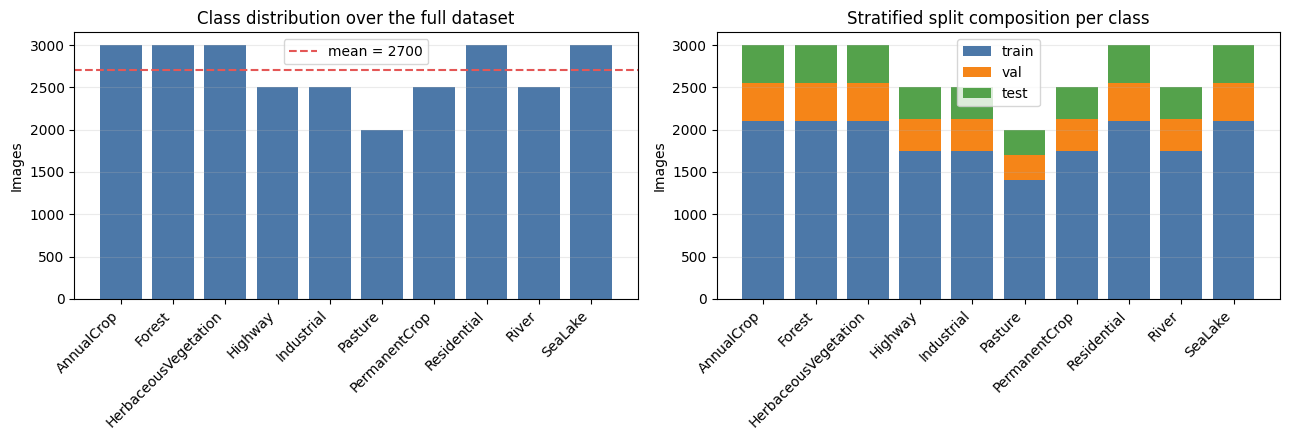

split,train,val,test,total,share %
label,,,,,
AnnualCrop,2100,450,450,3000,11.11
Forest,2100,450,450,3000,11.11
HerbaceousVegetation,2100,450,450,3000,11.11
Highway,1750,375,375,2500,9.26
Industrial,1750,375,375,2500,9.26
Pasture,1400,300,300,2000,7.41
PermanentCrop,1750,375,375,2500,9.26
Residential,2100,450,450,3000,11.11
River,1750,375,375,2500,9.26


Imbalance ratio (largest / smallest class): 1.50
Largest  : AnnualCrop (3,000 images)
Smallest : Pasture (2,000 images)
Per-class train share ranges 0.700-0.700 (stratification is exact)


In [4]:
# 5.1 Class distribution and split composition.
class_counts = split_df["label"].value_counts().reindex(CLASS_NAMES)
distribution = split_counts.copy()
distribution["total"] = class_counts
distribution["share %"] = (class_counts / len(split_df) * 100).round(2)
imbalance_ratio = class_counts.max() / class_counts.min()

figure, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(range(10), class_counts.to_numpy(), color="#4C78A8")
axes[0].axhline(class_counts.mean(), color="#E45756", linestyle="--",
                label=f"mean = {class_counts.mean():.0f}")
axes[0].set_xticks(range(10), CLASS_NAMES, rotation=45, ha="right")
axes[0].set(title="Class distribution over the full dataset", ylabel="Images")
axes[0].legend(); axes[0].grid(alpha=0.25, axis="y")

bottom = np.zeros(10)
for split_name, colour in zip(["train", "val", "test"], ["#4C78A8", "#F58518", "#54A24B"]):
    axes[1].bar(range(10), split_counts[split_name].to_numpy(), bottom=bottom,
                label=split_name, color=colour)
    bottom += split_counts[split_name].to_numpy()
axes[1].set_xticks(range(10), CLASS_NAMES, rotation=45, ha="right")
axes[1].set(title="Stratified split composition per class", ylabel="Images")
axes[1].legend(); axes[1].grid(alpha=0.25, axis="y")
figure.tight_layout()
plt.show()

split_share = (split_counts.T / split_counts.sum(axis=1)).T
display(distribution)
print(f"Imbalance ratio (largest / smallest class): {imbalance_ratio:.2f}")
print(f"Largest  : {class_counts.idxmax()} ({class_counts.max():,} images)")
print(f"Smallest : {class_counts.idxmin()} ({class_counts.min():,} images)")
print(f"Per-class train share ranges {split_share['train'].min():.3f}-{split_share['train'].max():.3f} "
      f"(stratification is exact)")

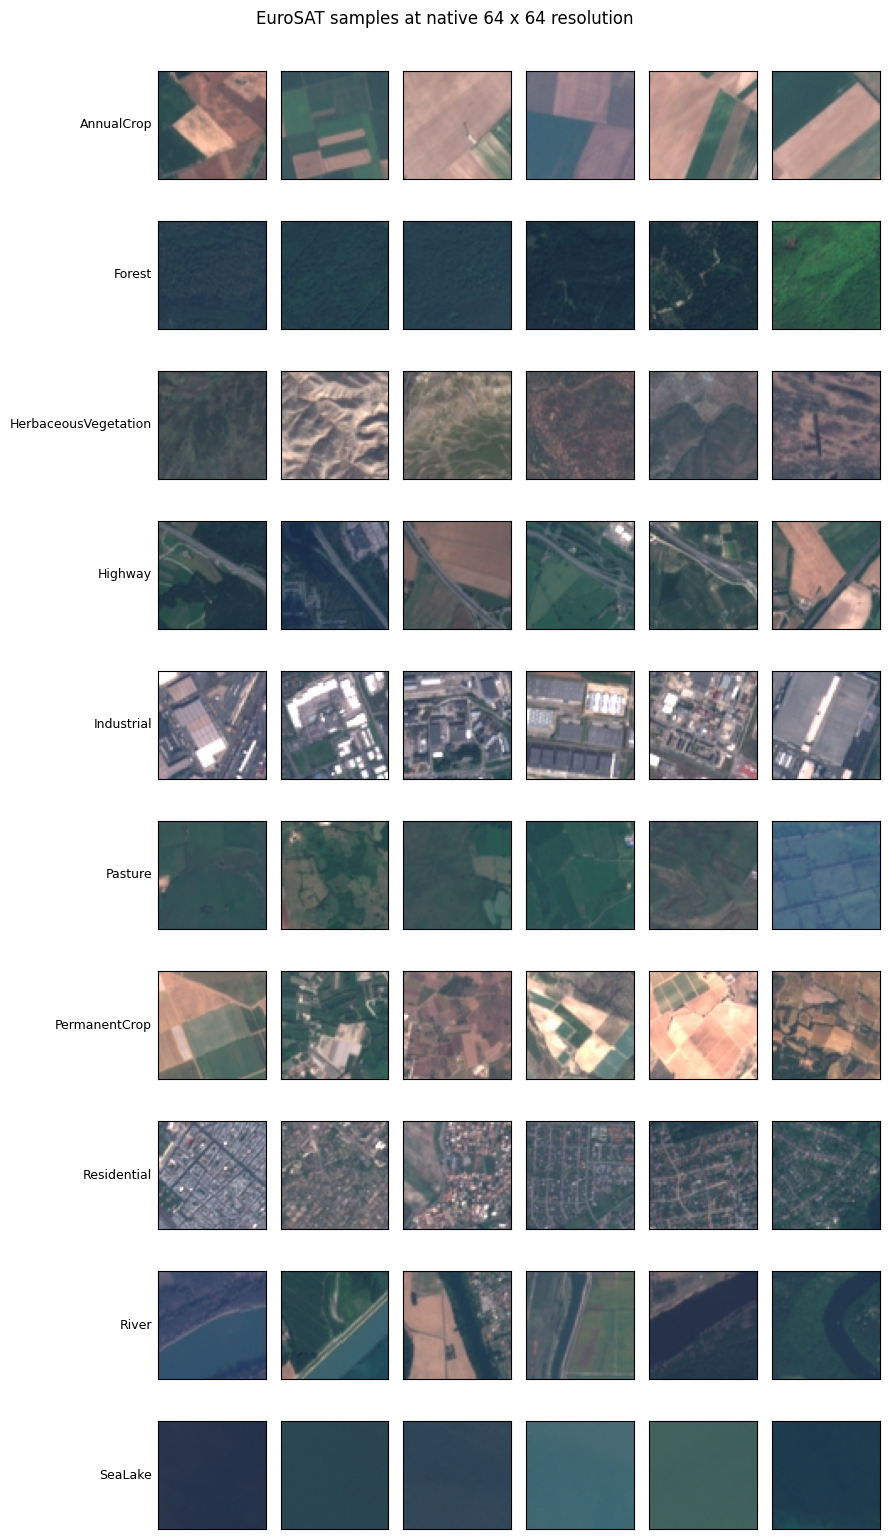

In [5]:
# 5.2 What the classes actually look like, at native resolution.
sample_rng = np.random.default_rng(SEED)
SAMPLES_PER_CLASS = 6

figure, axes = plt.subplots(10, SAMPLES_PER_CLASS, figsize=(9, 15.5))
for row, class_name in enumerate(CLASS_NAMES):
    pool = split_df.loc[split_df["label"] == class_name, "filepath"].to_numpy()
    for column, relative_path in enumerate(sample_rng.choice(pool, SAMPLES_PER_CLASS, replace=False)):
        axis = axes[row, column]
        axis.imshow(Image.open(DATA_ROOT / relative_path))
        axis.set_xticks([]); axis.set_yticks([])
        if column == 0:
            axis.set_ylabel(class_name, rotation=0, ha="right", va="center", fontsize=9)
figure.suptitle("EuroSAT samples at native 64 x 64 resolution", y=0.999)
figure.tight_layout()
plt.show()

In [6]:
# 5.3 Image properties, and what resizing to 224 x 224 really costs.
property_audit = split_df.sample(600, random_state=SEED)
observed_sizes, observed_modes = set(), set()
for relative_path in property_audit["filepath"]:
    with Image.open(DATA_ROOT / relative_path) as image:
        observed_sizes.add(image.size)
        observed_modes.add(image.mode)

assert len(observed_sizes) == 1, f"Patches are not uniform: {observed_sizes}"
native_size = observed_sizes.pop()
upscale_factor = IMAGE_SIZE / native_size[0]
GSD_METRES = 10

print(f"Audited {len(property_audit)} images")
print(f"  native size    : {native_size[0]} x {native_size[1]} px (uniform)")
print(f"  colour mode(s) : {observed_modes}")
print(f"  ground coverage: {native_size[0] * GSD_METRES / 1000:.2f} x "
      f"{native_size[1] * GSD_METRES / 1000:.2f} km at {GSD_METRES} m/px")
print()
print(f"Model input size : {IMAGE_SIZE} x {IMAGE_SIZE} px")
print(f"  upscale factor : {upscale_factor:.2f}x linear, {upscale_factor ** 2:.1f}x pixel count")
print(f"  effective GSD  : {GSD_METRES / upscale_factor:.2f} m/px of *interpolated* detail")

Audited 600 images
  native size    : 64 x 64 px (uniform)
  colour mode(s) : {'RGB'}
  ground coverage: 0.64 x 0.64 km at 10 m/px

Model input size : 224 x 224 px
  upscale factor : 3.50x linear, 12.2x pixel count
  effective GSD  : 2.86 m/px of *interpolated* detail


In [7]:
# 5.4 Is colour alone enough to separate the classes?
colour_rng = np.random.default_rng(0)
IMAGES_PER_CLASS = 150

class_colour_means = []
for class_name in CLASS_NAMES:
    pool = split_df.loc[
        (split_df["label"] == class_name) & (split_df["split"] == "train"), "filepath"
    ].to_numpy()
    picks = colour_rng.choice(pool, IMAGES_PER_CLASS, replace=False)
    per_image_mean = np.stack([
        np.asarray(Image.open(DATA_ROOT / p), dtype=np.float32).reshape(-1, 3).mean(axis=0)
        for p in picks
    ])
    class_colour_means.append(per_image_mean.mean(axis=0))

colour_frame = pd.DataFrame(class_colour_means, index=CLASS_NAMES, columns=["R", "G", "B"])
centroids = colour_frame.to_numpy()
colour_distance = np.linalg.norm(centroids[:, None, :] - centroids[None, :, :], axis=-1)

closest_pairs = sorted(
    (colour_distance[i, j], CLASS_NAMES[i], CLASS_NAMES[j])
    for i in range(10) for j in range(i + 1, 10)
)
closest_frame = pd.DataFrame(
    [{"class pair": f"{a} / {b}", "mean-RGB distance": round(d, 1)} for d, a, b in closest_pairs[:5]]
)

display(colour_frame.round(1))
print("Five closest class pairs in mean-RGB space:")
display(closest_frame)

,R,G,B
AnnualCrop,130.500000,120.900002,117.900002
Forest,39.200001,64.599998,75.699997
HerbaceousVegetation,92.699997,95.800003,101.599998
Highway,88.900002,97.000000,102.800003
Industrial,124.000000,125.699997,134.800003
Pasture,63.200001,89.500000,97.099998
PermanentCrop,121.800003,115.199997,113.500000
Residential,97.099998,101.599998,110.800003
River,67.900002,87.199997,98.699997
SeaLake,48.900002,73.800003,89.699997


Five closest class pairs in mean-RGB space:


,class pair,mean-RGB distance
0,HerbaceousVegetation / Highway,4.1
1,Pasture / River,5.5
2,AnnualCrop / PermanentCrop,11.3
3,HerbaceousVegetation / Residential,11.7
4,Highway / Residential,12.3


### 5.5 Implications for modelling

Class imbalance is mild. The largest class has 1.5x as many images as the smallest (3,000
AnnualCrop vs 2,000 Pasture), and every class retains at least 1,400 training images. The
stratified split preserves these proportions to three decimal places. We use unweighted
cross-entropy and also report macro-F1, which gives each class equal weight in evaluation.

Upsampling from 64 x 64 to 224 x 224 creates twelve times as many pixels without adding spatial
information. It is required only by the ImageNet-pretrained backbones; the 10 m ground
resolution does not change. Detail that might separate a highway from a field boundary is not
recovered by resizing.

The sample grid points to the agricultural classes as the difficult group. AnnualCrop,
PermanentCrop, HerbaceousVegetation and Pasture share similar green-to-brown field textures,
whereas Forest, Residential, Industrial and SeaLake are more visually distinct. Section 10.2
checks whether the errors follow this pattern.

Mean RGB is a poor guide to these confusions. HerbaceousVegetation / Highway and Pasture / River
are the closest pairs in mean-RGB space but are rarely confused. Most errors instead occur
between AnnualCrop / PermanentCrop and HerbaceousVegetation / PermanentCrop, even though these
pairs are farther apart in colour. The pattern implicates spatial texture and layout. It agrees
with Helber et al.'s result that deep CNNs outperform Bag-of-Visual-Words by roughly 28 accuracy
points on EuroSAT. Colour jitter remains appropriate because average colour is unreliable and
some images retain the atmospheric colour casts described in Section 2.

## 6. Models, training protocol and attribution

### 6.1 Shared training protocol

Every model below is trained through the same harness, split, transforms and hyperparameters.
Architecture is the main systematic difference; minibatch order and stochastic augmentation
remain sources of run-to-run variation, which Section 12 measures across three seeds.

| Setting | Value |
|---|---|
| Initialisation | ImageNet-1k pretrained, full fine-tuning (no frozen layers) |
| Classifier head | Final layer replaced, 1000 -> 10 outputs |
| Input | 224 x 224 RGB, ImageNet channel normalisation |
| Augmentation (train only) | RandomResizedCrop (scale 0.90-1.0, ratio 0.90-1.10), horizontal + vertical flip (p=0.5), rotation up to 90°, colour jitter (brightness/contrast 0.20, saturation 0.15, hue 0.03) |
| Optimiser | AdamW, learning rate 1e-4, weight decay 1e-4 |
| Schedule | Cosine annealing over 20 epochs to 1e-6 |
| Loss | Unweighted cross-entropy (justified in Section 5.5) |
| Batch size | 32 |
| Precision | Mixed precision (AMP) |
| Seed | 42, set immediately before each model is constructed |
| Model selection | Checkpoint with the best **validation** macro-F1 |
| Test usage | Once per predefined training run, on the validation-selected checkpoint only |

Augmentation applies to the training split only; validation and test images are deterministically resized and normalised. Both pipelines are defined in `src/data/transforms.py` and reach the models through the shared `create_dataloaders` factory (Section 3), so all three models use the same data split and transform definitions. Flips and rotations are safe here because satellite patches have no canonical orientation.

Checkpoint selection uses macro-F1, giving every class equal weight despite the mild imbalance.

### 6.2 Attribution

**External components:**

- ResNet50 and EfficientNet-B0 architectures and their torchvision ImageNet-1k weights.
- DeiT-Tiny/16 architecture and its `timm` ImageNet-1k weights (Touvron et al., Facebook AI).
- The EuroSAT dataset itself (Helber et al., 2019).
- The `src.data` package — `Dataset`, transforms, stratified split generation and the
  `create_dataloaders` factory — written by our group's data-preprocessing member and imported
  unmodified in Section 3 so that every model provably sees identical data.

**Work completed for this notebook:** the leakage and integrity audit (Section 4), all exploratory
analysis (Section 5), the training / evaluation harness below including the confusion-matrix
metric implementation, checkpoint selection, and all comparison and error analysis in
Sections 10-13. Only each model's final classification layer is modified, from 1000 ImageNet
classes to the 10 EuroSAT classes.

In [8]:
def confusion_from_predictions(targets, predictions, num_classes):
    indices = targets.to(torch.int64) * num_classes + predictions.to(torch.int64)
    return torch.bincount(indices, minlength=num_classes**2).reshape(num_classes, num_classes)


def metrics_from_confusion(confusion):
    matrix = confusion.to(torch.float64)
    support = matrix.sum(dim=1)
    predicted = matrix.sum(dim=0)
    true_positive = matrix.diag()
    precision = torch.where(predicted > 0, true_positive / predicted, 0.0)
    recall = torch.where(support > 0, true_positive / support, 0.0)
    f1 = torch.where(precision + recall > 0, 2 * precision * recall / (precision + recall), 0.0)
    return {
        "accuracy": float(true_positive.sum() / matrix.sum()),
        "macro_f1": float(f1.mean()),
        "precision_per_class": precision.tolist(),
        "recall_per_class": recall.tolist(),
        "f1_per_class": f1.tolist(),
        "confusion_matrix": confusion.tolist(),
    }


def run_epoch(model, loader, criterion, device, num_classes, optimizer=None, scaler=None, use_amp=False):
    training = optimizer is not None
    model.train(training)
    total_loss = 0.0
    total_examples = 0
    confusion = torch.zeros((num_classes, num_classes), dtype=torch.int64)
    started = time.perf_counter()

    for images, targets in loader:
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)
        if training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(training):
            with torch.amp.autocast(device_type=device.type, enabled=use_amp):
                logits = model(images)
                loss = criterion(logits, targets)  # CrossEntropy loss for this batch
            if training:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

        predictions = logits.argmax(dim=1)
        batch_size = targets.size(0)
        total_loss += float(loss.detach()) * batch_size
        total_examples += batch_size
        confusion += confusion_from_predictions(
            targets.detach().cpu(), predictions.detach().cpu(), num_classes
        )

    metrics = metrics_from_confusion(confusion)
    metrics["loss"] = total_loss / total_examples  # mean epoch loss
    metrics["samples"] = total_examples
    metrics["seconds"] = time.perf_counter() - started
    return metrics


def save_training_curves(history, path):
    frame = pd.DataFrame(history)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(frame["epoch"], frame["train_loss"], label="Train")
    axes[0].plot(frame["epoch"], frame["val_loss"], label="Validation")
    axes[0].set(title="Loss", xlabel="Epoch")
    axes[1].plot(frame["epoch"], frame["train_accuracy"], label="Train")
    axes[1].plot(frame["epoch"], frame["val_accuracy"], label="Validation")
    axes[1].set(title="Accuracy", xlabel="Epoch")
    axes[2].plot(frame["epoch"], frame["train_macro_f1"], label="Train")
    axes[2].plot(frame["epoch"], frame["val_macro_f1"], label="Validation")
    axes[2].set(title="Macro-F1", xlabel="Epoch")
    for axis in axes:
        axis.grid(alpha=0.25)
        axis.legend()
    fig.tight_layout()
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.close(fig)


def save_normalized_confusion(confusion_matrix, class_names, path):
    matrix = np.asarray(confusion_matrix, dtype=float)
    normalized = np.divide(
        matrix,
        matrix.sum(axis=1, keepdims=True),
        out=np.zeros_like(matrix),
        where=matrix.sum(axis=1, keepdims=True) != 0,
    )
    fig, axis = plt.subplots(figsize=(8, 7))
    image = axis.imshow(normalized, cmap="Blues", vmin=0, vmax=1)
    axis.set_xticks(range(len(class_names)), class_names, rotation=45, ha="right")
    axis.set_yticks(range(len(class_names)), class_names)
    axis.set(xlabel="Predicted", ylabel="True", title="Normalized confusion matrix")
    fig.colorbar(image, ax=axis, fraction=0.046, pad=0.04)
    fig.tight_layout()
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.close(fig)


def train_and_evaluate(model, loaders, device, model_name, output_dir, epochs=20):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    checkpoint_path = output_dir / "best_model.pt"

    criterion = nn.CrossEntropyLoss()
    optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = CosineAnnealingLR(
        optimizer, T_max=epochs, eta_min=LEARNING_RATE * 0.01
    )
    use_amp = device.type == "cuda"
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

    history = []
    best_epoch = 0
    best_val_macro_f1 = -1.0
    training_started = time.perf_counter()

    print(f"{model_name}: starting real {epochs}-epoch training")
    for epoch in range(1, epochs + 1):
        learning_rate = optimizer.param_groups[0]["lr"]
        train_metrics = run_epoch(
            model, loaders["train"], criterion, device, len(CLASS_NAMES),
            optimizer=optimizer, scaler=scaler, use_amp=use_amp,
        )
        val_metrics = run_epoch(
            model, loaders["validation"], criterion, device, len(CLASS_NAMES),
            scaler=scaler, use_amp=use_amp,
        )

        row = {
            "epoch": epoch,
            "learning_rate": learning_rate,
            "train_loss": train_metrics["loss"],
            "train_accuracy": train_metrics["accuracy"],
            "train_macro_f1": train_metrics["macro_f1"],
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
            "val_macro_f1": val_metrics["macro_f1"],
            "train_seconds": train_metrics["seconds"],
            "val_seconds": val_metrics["seconds"],
        }
        history.append(row)
        pd.DataFrame(history).to_csv(output_dir / "history.csv", index=False)

        is_best = val_metrics["macro_f1"] > best_val_macro_f1
        if is_best:
            best_val_macro_f1 = val_metrics["macro_f1"]
            best_epoch = epoch
            torch.save(model.state_dict(), checkpoint_path)

        marker = "  <-- saved new best_model.pt" if is_best else ""
        print(
            f"Epoch {epoch:02d}/{epochs} | lr={learning_rate:.6g} | "
            f"train loss={train_metrics['loss']:.4f}, acc={train_metrics['accuracy']:.4f}, "
            f"macro-F1={train_metrics['macro_f1']:.4f} | "
            f"val loss={val_metrics['loss']:.4f}, acc={val_metrics['accuracy']:.4f}, "
            f"macro-F1={val_metrics['macro_f1']:.4f}{marker}",
            flush=True,
        )
        scheduler.step()

    assert len(history) == epochs
    calculated_best = max(history, key=lambda item: item["val_macro_f1"])
    assert calculated_best["epoch"] == best_epoch
    assert checkpoint_path.is_file()

    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    test_metrics = run_epoch(
        model, loaders["test"], criterion, device, len(CLASS_NAMES),
        scaler=scaler, use_amp=use_amp,
    )
    training_seconds = time.perf_counter() - training_started

    summary = {
        "status": "training_complete",
        "epochs_completed": len(history),
        "best_epoch": best_epoch,
        "best_validation_macro_f1": best_val_macro_f1,
        "best_validation_loss": calculated_best["val_loss"],
        "test_loss": test_metrics["loss"],
        "test_accuracy": test_metrics["accuracy"],
        "test_macro_f1": test_metrics["macro_f1"],
        "training_seconds": training_seconds,
        "checkpoint": str(checkpoint_path.relative_to(PROJECT_ROOT)),
    }
    (output_dir / "summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
    (output_dir / "test_metrics.json").write_text(json.dumps(test_metrics, indent=2), encoding="utf-8")
    save_training_curves(history, output_dir / "training_curves.png")
    save_normalized_confusion(
        test_metrics["confusion_matrix"], CLASS_NAMES,
        output_dir / "confusion_matrix_normalized.png",
    )

    print(f"Training completed: {len(history)}/{epochs} epochs")
    print(f"Best model: epoch {best_epoch}, validation macro-F1={best_val_macro_f1:.4f}")
    print(
        f"Held-out test: loss={test_metrics['loss']:.4f}, "
        f"accuracy={test_metrics['accuracy']:.4f}, macro-F1={test_metrics['macro_f1']:.4f}"
    )
    return history, summary, test_metrics


print("Training code loaded: loss calculation, 20-epoch loop, best-checkpoint rule and test evaluation are active.")

Training code loaded: loss calculation, 20-epoch loop, best-checkpoint rule and test evaluation are active.


## 7. ResNet50 — 20-epoch fine-tuning

ResNet50 provides the reference point because the EuroSAT authors used this residual CNN in their published benchmark.

In [9]:
def create_resnet50(num_classes=10):
    model = resnet50(weights=ResNet50_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

set_seed(SEED)
resnet_model = create_resnet50(len(CLASS_NAMES)).to(device)
print(f"ResNet50 parameters: {sum(parameter.numel() for parameter in resnet_model.parameters()):,}")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to c:\Users\loy\Desktop\9444-project-\outputs\_torch_cache\hub\checkpoints\resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:07<00:00, 13.5MB/s]

ResNet50 parameters: 23,528,522


In [10]:
resnet_history, resnet_summary, resnet_test_metrics = train_and_evaluate(
    model=resnet_model,
    loaders=loaders,
    device=device,
    model_name="ResNet50",
    output_dir=RESNET_OUTPUT,
    epochs=EPOCHS,
)

ResNet50: starting real 20-epoch training
Epoch 01/20 | lr=0.0001 | train loss=0.3999, acc=0.8767, macro-F1=0.8739 | val loss=0.1133, acc=0.9630, macro-F1=0.9620  <-- saved new best_model.pt
Epoch 02/20 | lr=9.93906e-05 | train loss=0.1476, acc=0.9496, macro-F1=0.9485 | val loss=0.0865, acc=0.9716, macro-F1=0.9707  <-- saved new best_model.pt
Epoch 03/20 | lr=9.75773e-05 | train loss=0.1090, acc=0.9632, macro-F1=0.9625 | val loss=0.0923, acc=0.9679, macro-F1=0.9675
Epoch 04/20 | lr=9.46048e-05 | train loss=0.0885, acc=0.9701, macro-F1=0.9695 | val loss=0.0832, acc=0.9721, macro-F1=0.9718  <-- saved new best_model.pt
Epoch 05/20 | lr=9.05463e-05 | train loss=0.0798, acc=0.9723, macro-F1=0.9715 | val loss=0.0661, acc=0.9775, macro-F1=0.9769  <-- saved new best_model.pt
Epoch 06/20 | lr=8.55018e-05 | train loss=0.0672, acc=0.9776, macro-F1=0.9771 | val loss=0.0804, acc=0.9709, macro-F1=0.9701
Epoch 07/20 | lr=7.95954e-05 | train loss=0.0608, acc=0.9790, macro-F1=0.9786 | val loss=0.0594, 

In [1]:
assert resnet_summary["epochs_completed"] == 20

display(pd.DataFrame(resnet_history).round(4))
display(pd.Series(resnet_summary, name="ResNet50 result"))

figure, axes = plt.subplots(1, 2, figsize=(16, 6))

history_frame = pd.DataFrame(resnet_history)

# Loss curves
axes[0].plot(
    history_frame["epoch"],
    history_frame["train_loss"],
    label="Train loss"
)
axes[0].plot(
    history_frame["epoch"],
    history_frame["val_loss"],
    label="Validation loss"
)

axes[0].set(
    title="ResNet50 loss",
    xlabel="Epoch",
    ylabel="Loss"
)

axes[0].grid(alpha=0.25)
axes[0].legend()

# Normalized confusion matrix
matrix = np.asarray(
    resnet_test_metrics["confusion_matrix"],
    dtype=float
)

row_sums = matrix.sum(axis=1, keepdims=True)

# 避免某一类别没有样本时出现除以 0
matrix = np.divide(
    matrix,
    row_sums,
    out=np.zeros_like(matrix),
    where=row_sums != 0
)

image = axes[1].imshow(
    matrix,
    cmap="Blues",
    vmin=0,
    vmax=1
)

axes[1].set(
    title="ResNet50 normalized confusion matrix",
    xlabel="Predicted",
    ylabel="True"
)

axes[1].set_xticks(
    range(len(CLASS_NAMES)),
    CLASS_NAMES,
    rotation=45,
    ha="right"
)

axes[1].set_yticks(
    range(len(CLASS_NAMES)),
    CLASS_NAMES
)

# 在每个格子中显示数值
for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        value = matrix[i, j]

        axes[1].text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=7,
            fontweight="bold",
            color="white" if value >= 0.50 else "black"
        )

# 添加颜色条
figure.colorbar(
    image,
    ax=axes[1],
    fraction=0.046,
    pad=0.04,
    label="Proportion"
)

figure.tight_layout()
plt.show()

NameError: name 'resnet_summary' is not defined

## 8. EfficientNet-B0 — 20-epoch fine-tuning

EfficientNet-B0 is a compound-scaled CNN with roughly one sixth of ResNet50's parameters. Its results measure the accuracy retained by a much smaller convolutional model.

In [12]:
def create_efficientnet_b0(num_classes=10):
    model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    return model

set_seed(SEED)
efficientnet_model = create_efficientnet_b0(len(CLASS_NAMES)).to(device)
print(f"EfficientNet-B0 parameters: {sum(parameter.numel() for parameter in efficientnet_model.parameters()):,}")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to c:\Users\loy\Desktop\9444-project-\outputs\_torch_cache\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:01<00:00, 13.7MB/s]

EfficientNet-B0 parameters: 4,020,358


In [13]:
efficientnet_history, efficientnet_summary, efficientnet_test_metrics = train_and_evaluate(
    model=efficientnet_model,
    loaders=loaders,
    device=device,
    model_name="EfficientNet-B0",
    output_dir=EFFICIENTNET_OUTPUT,
    epochs=EPOCHS,
)

EfficientNet-B0: starting real 20-epoch training
Epoch 01/20 | lr=0.0001 | train loss=0.4641, acc=0.8687, macro-F1=0.8655 | val loss=0.1535, acc=0.9516, macro-F1=0.9510  <-- saved new best_model.pt
Epoch 02/20 | lr=9.93906e-05 | train loss=0.1661, acc=0.9459, macro-F1=0.9449 | val loss=0.0893, acc=0.9691, macro-F1=0.9684  <-- saved new best_model.pt
Epoch 03/20 | lr=9.75773e-05 | train loss=0.1266, acc=0.9586, macro-F1=0.9577 | val loss=0.0803, acc=0.9706, macro-F1=0.9699  <-- saved new best_model.pt
Epoch 04/20 | lr=9.46048e-05 | train loss=0.1022, acc=0.9660, macro-F1=0.9654 | val loss=0.0774, acc=0.9751, macro-F1=0.9746  <-- saved new best_model.pt
Epoch 05/20 | lr=9.05463e-05 | train loss=0.0895, acc=0.9698, macro-F1=0.9691 | val loss=0.0690, acc=0.9790, macro-F1=0.9786  <-- saved new best_model.pt
Epoch 06/20 | lr=8.55018e-05 | train loss=0.0774, acc=0.9734, macro-F1=0.9728 | val loss=0.0561, acc=0.9822, macro-F1=0.9815  <-- saved new best_model.pt
Epoch 07/20 | lr=7.95954e-05 | t

,epoch,learning_rate,train_loss,train_accuracy,train_macro_f1,val_loss,val_accuracy,val_macro_f1,train_seconds,val_seconds
0,1,0.0001,0.4641,0.8687,0.8655,0.1535,0.9516,0.9510,23.4238,1.5842
1,2,0.0001,0.1661,0.9459,0.9449,0.0893,0.9691,0.9684,22.6626,1.5141
2,3,0.0001,0.1266,0.9586,0.9577,0.0803,0.9706,0.9699,22.3826,1.6310
3,4,0.0001,0.1022,0.9660,0.9654,0.0774,0.9751,0.9746,22.2876,1.5418
4,5,0.0001,0.0895,0.9698,0.9691,0.0690,0.9790,0.9786,22.4911,1.5350
5,6,0.0001,0.0774,0.9734,0.9728,0.0561,0.9822,0.9815,22.2643,1.4969
6,7,0.0001,0.0729,0.9758,0.9751,0.0745,0.9756,0.9752,22.3908,1.4706
7,8,0.0001,0.0620,0.9797,0.9793,0.0621,0.9812,0.9808,22.2983,1.5270
8,9,0.0001,0.0576,0.9810,0.9804,0.0638,0.9790,0.9784,22.2986,1.5366
9,10,0.0001,0.0513,0.9830,0.9825,0.0618,0.9793,0.9788,22.2764,1.4931


status                                                      training_complete
epochs_completed                                                           20
best_epoch                                                                 17
best_validation_macro_f1                                             0.982504
best_validation_loss                                                 0.054689
test_loss                                                            0.045043
test_accuracy                                                         0.98642
test_macro_f1                                                        0.986072
training_seconds                                                   490.788108
checkpoint                  outputs\notebook_efficientnet_b0_20epochs\best...
Name: EfficientNet-B0 result, dtype: object

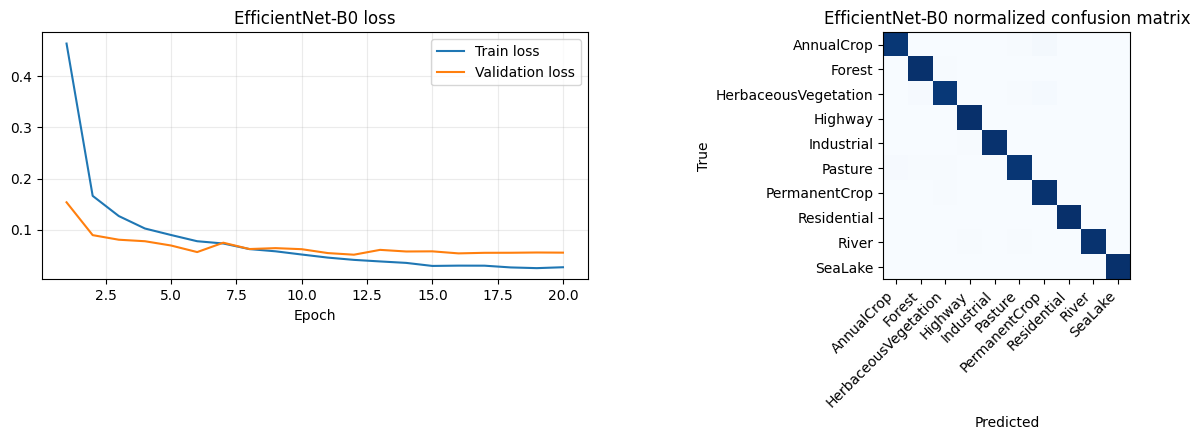

In [ ]:
assert efficientnet_summary["epochs_completed"] == 20

display(pd.DataFrame(efficientnet_history).round(4))
display(pd.Series(efficientnet_summary, name="EfficientNet-B0 result"))

figure, axes = plt.subplots(1, 2, figsize=(16, 6))

history_frame = pd.DataFrame(efficientnet_history)

# Loss curves
axes[0].plot(
    history_frame["epoch"],
    history_frame["train_loss"],
    label="Train loss"
)
axes[0].plot(
    history_frame["epoch"],
    history_frame["val_loss"],
    label="Validation loss"
)

axes[0].set(
    title="EfficientNet-B0 loss",
    xlabel="Epoch",
    ylabel="Loss"
)

axes[0].grid(alpha=0.25)
axes[0].legend()

# Normalized confusion matrix
matrix = np.asarray(
    efficientnet_test_metrics["confusion_matrix"],
    dtype=float
)

row_sums = matrix.sum(axis=1, keepdims=True)

matrix = np.divide(
    matrix,
    row_sums,
    out=np.zeros_like(matrix),
    where=row_sums != 0
)

image = axes[1].imshow(
    matrix,
    cmap="Blues",
    vmin=0,
    vmax=1
)

axes[1].set(
    title="EfficientNet-B0 normalized confusion matrix",
    xlabel="Predicted",
    ylabel="True"
)

axes[1].set_xticks(
    range(len(CLASS_NAMES)),
    CLASS_NAMES,
    rotation=45,
    ha="right"
)

axes[1].set_yticks(
    range(len(CLASS_NAMES)),
    CLASS_NAMES
)

# 在每个格子中显示数值
for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        value = matrix[i, j]

        axes[1].text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=7,
            fontweight="bold",
            color="white" if value >= 0.5 else "black"
        )

# 添加颜色条
figure.colorbar(
    image,
    ax=axes[1],
    fraction=0.046,
    pad=0.04,
    label="Proportion"
)

figure.tight_layout()
plt.show()

## 9. DeiT-Tiny/16 — 20-epoch fine-tuning

DeiT-Tiny/16 is a distillation-trained Vision Transformer. Its 5.5M parameters are close to EfficientNet-B0, providing a roughly size-matched comparison between attention and convolution.

In [15]:
def create_deit_tiny(num_classes=10):
    try:
        import timm
    except ModuleNotFoundError as error:
        raise ModuleNotFoundError(
            "DeiT-Tiny requires timm. Install it with: pip install timm"
        ) from error
    return timm.create_model(
        "deit_tiny_patch16_224",
        pretrained=True,
        num_classes=num_classes,
    )

DEIT_OUTPUT = PROJECT_ROOT / "outputs" / "notebook_deit_tiny_20epochs"

set_seed(SEED)
deit_model = create_deit_tiny(len(CLASS_NAMES)).to(device)
print(f"DeiT-Tiny parameters: {sum(parameter.numel() for parameter in deit_model.parameters()):,}")

model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

DeiT-Tiny parameters: 5,526,346


c:\Users\loy\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\loy\.cache\huggingface\hub\models--timm--deit_tiny_patch16_224.fb_in1k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


In [ ]:
deit_history, deit_summary, deit_test_metrics = train_and_evaluate(
    model=deit_model,
    loaders=loaders,
    device=device,
    model_name="DeiT-Tiny/16",
    output_dir=DEIT_OUTPUT,
    epochs=EPOCHS,
)

DeiT-Tiny/16: starting real 20-epoch training
Epoch 01/20 | lr=0.0001 | train loss=0.2706, acc=0.9157, macro-F1=0.9137 | val loss=0.1338, acc=0.9600, macro-F1=0.9597  <-- saved new best_model.pt
Epoch 02/20 | lr=9.93906e-05 | train loss=0.1292, acc=0.9579, macro-F1=0.9571 | val loss=0.0934, acc=0.9659, macro-F1=0.9651  <-- saved new best_model.pt
Epoch 03/20 | lr=9.75773e-05 | train loss=0.1028, acc=0.9652, macro-F1=0.9644 | val loss=0.1193, acc=0.9615, macro-F1=0.9609
Epoch 04/20 | lr=9.46048e-05 | train loss=0.0920, acc=0.9689, macro-F1=0.9684 | val loss=0.0827, acc=0.9756, macro-F1=0.9746  <-- saved new best_model.pt
Epoch 05/20 | lr=9.05463e-05 | train loss=0.0790, acc=0.9737, macro-F1=0.9732 | val loss=0.1110, acc=0.9649, macro-F1=0.9646


,epoch,learning_rate,train_loss,train_accuracy,train_macro_f1,val_loss,val_accuracy,val_macro_f1,train_seconds,val_seconds
0,1,0.0001,0.2670,0.9159,0.9136,0.1573,0.9479,0.9455,23.1342,2.0016
1,2,0.0001,0.1294,0.9580,0.9569,0.0822,0.9711,0.9705,23.3636,1.9808
2,3,0.0001,0.1099,0.9616,0.9608,0.0913,0.9701,0.9696,23.3173,2.0262
3,4,0.0001,0.0885,0.9705,0.9699,0.0884,0.9701,0.9692,23.5416,2.0918
4,5,0.0001,0.0797,0.9735,0.9727,0.1189,0.9583,0.9580,23.2325,2.4108
5,6,0.0001,0.0670,0.9763,0.9758,0.0644,0.9785,0.9779,23.4496,2.0296
6,7,0.0001,0.0604,0.9801,0.9795,0.0637,0.9802,0.9797,23.2119,2.1017
7,8,0.0001,0.0551,0.9819,0.9815,0.0780,0.9765,0.9758,23.1095,2.1827
8,9,0.0001,0.0509,0.9829,0.9824,0.0781,0.9733,0.9725,23.3033,2.0727
9,10,0.0001,0.0436,0.9848,0.9845,0.0637,0.9790,0.9784,23.4433,2.1624


status                                                      training_complete
epochs_completed                                                           20
best_epoch                                                                 20
best_validation_macro_f1                                             0.988076
best_validation_loss                                                 0.038971
test_loss                                                            0.047172
test_accuracy                                                        0.986173
test_macro_f1                                                        0.985799
training_seconds                                                   511.312191
checkpoint                  outputs/notebook_deit_tiny_20epochs/best_model.pt
Name: DeiT-Tiny/16 result, dtype: object

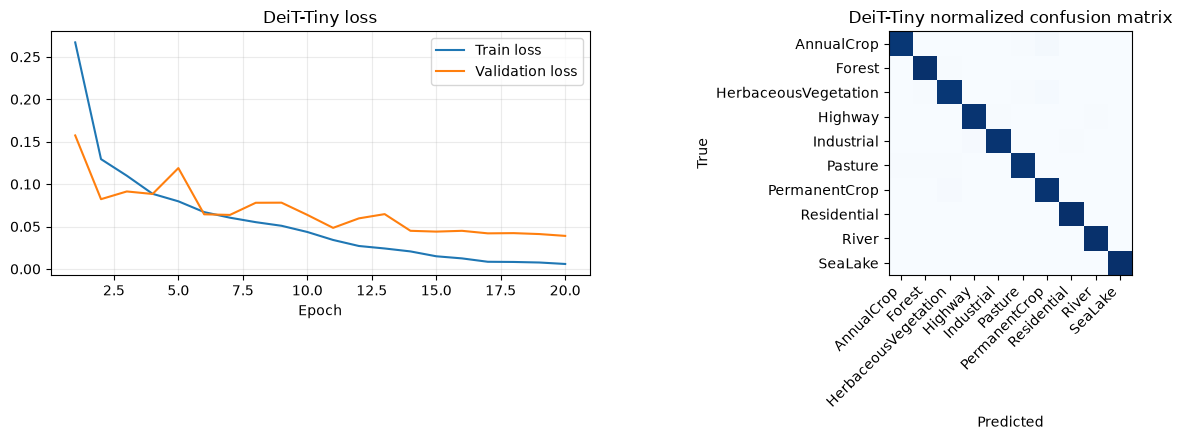

In [ ]:
assert deit_summary["epochs_completed"] == 20

display(pd.DataFrame(deit_history).round(4))
display(pd.Series(deit_summary, name="DeiT-Tiny/16 result"))

figure, axes = plt.subplots(1, 2, figsize=(16, 6))

history_frame = pd.DataFrame(deit_history)

# Loss curves
axes[0].plot(
    history_frame["epoch"],
    history_frame["train_loss"],
    label="Train loss"
)
axes[0].plot(
    history_frame["epoch"],
    history_frame["val_loss"],
    label="Validation loss"
)

axes[0].set(
    title="DeiT-Tiny loss",
    xlabel="Epoch",
    ylabel="Loss"
)

axes[0].grid(alpha=0.25)
axes[0].legend()

# Normalized confusion matrix
matrix = np.asarray(
    deit_test_metrics["confusion_matrix"],
    dtype=float
)

row_sums = matrix.sum(axis=1, keepdims=True)

matrix = np.divide(
    matrix,
    row_sums,
    out=np.zeros_like(matrix),
    where=row_sums != 0
)

image = axes[1].imshow(
    matrix,
    cmap="Blues",
    vmin=0,
    vmax=1
)

axes[1].set(
    title="DeiT-Tiny normalized confusion matrix",
    xlabel="Predicted",
    ylabel="True"
)

axes[1].set_xticks(
    range(len(CLASS_NAMES)),
    CLASS_NAMES,
    rotation=45,
    ha="right"
)

axes[1].set_yticks(
    range(len(CLASS_NAMES)),
    CLASS_NAMES
)

# 在每个格子中显示百分比
for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        value = matrix[i, j]

        axes[1].text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=7,
            fontweight="bold",
            color="white" if value >= 0.5 else "black"
        )

# 添加颜色条
figure.colorbar(
    image,
    ax=axes[1],
    fraction=0.046,
    pad=0.04,
    label="Proportion"
)

figure.tight_layout()
plt.show()

## 10. Cross-model comparison

In [ ]:
# 10.1 Headline comparison across all three architectures.
MODEL_RESULTS = [
    ("ResNet50", resnet_model, resnet_summary, resnet_test_metrics),
    ("EfficientNet-B0", efficientnet_model, efficientnet_summary, efficientnet_test_metrics),
    ("DeiT-Tiny/16", deit_model, deit_summary, deit_test_metrics),
]

comparison_rows = []
for name, model, summary, test_metrics in MODEL_RESULTS:
    confusion = np.asarray(test_metrics["confusion_matrix"])
    comparison_rows.append({
        "parameters (M)": round(sum(p.numel() for p in model.parameters()) / 1e6, 2),
        "test accuracy %": round(test_metrics["accuracy"] * 100, 2),
        "test macro-F1 %": round(test_metrics["macro_f1"] * 100, 2),
        "test errors": int(confusion.sum() - np.trace(confusion)),
        "val macro-F1 %": round(summary["best_validation_macro_f1"] * 100, 2),
        "best epoch": summary["best_epoch"],
        "train time (s)": round(summary["training_seconds"]),
        "checkpoint (MB)": round(Path(summary["checkpoint"]).stat().st_size / 1e6, 1),
    })

comparison = pd.DataFrame(comparison_rows, index=[row[0] for row in MODEL_RESULTS])
display(comparison)

test_images = int(np.asarray(resnet_test_metrics["confusion_matrix"]).sum())
accuracy_spread = comparison["test accuracy %"].max() - comparison["test accuracy %"].min()
print(f"Test set: {test_images:,} images")
print(f"Accuracy spread across the three models: {accuracy_spread:.2f} percentage points "
      f"= {accuracy_spread / 100 * test_images:.0f} images")
print(f"Most accurate    : {comparison['test accuracy %'].idxmax()}")
print(f"Most parameter-efficient : {comparison['parameters (M)'].idxmin()} "
      f"({comparison['parameters (M)'].min()}M parameters)")
print(f"Fastest to train : {comparison['train time (s)'].idxmin()} "
      f"({comparison['train time (s)'].min()} s)")

,parameters (M),test accuracy %,test macro-F1 %,test errors,val macro-F1 %,best epoch,train time (s),checkpoint (MB)
ResNet50,23.53,98.74,98.70,51,98.78,17,524,94.4
EfficientNet-B0,4.02,98.52,98.48,60,98.24,19,683,16.4
DeiT-Tiny/16,5.53,98.62,98.58,56,98.81,20,511,22.2


Test set: 4,050 images
Accuracy spread across the three models: 0.22 percentage points = 9 images
Most accurate    : ResNet50
Most parameter-efficient : EfficientNet-B0 (4.02M parameters)
Fastest to train : DeiT-Tiny/16 (511 s)


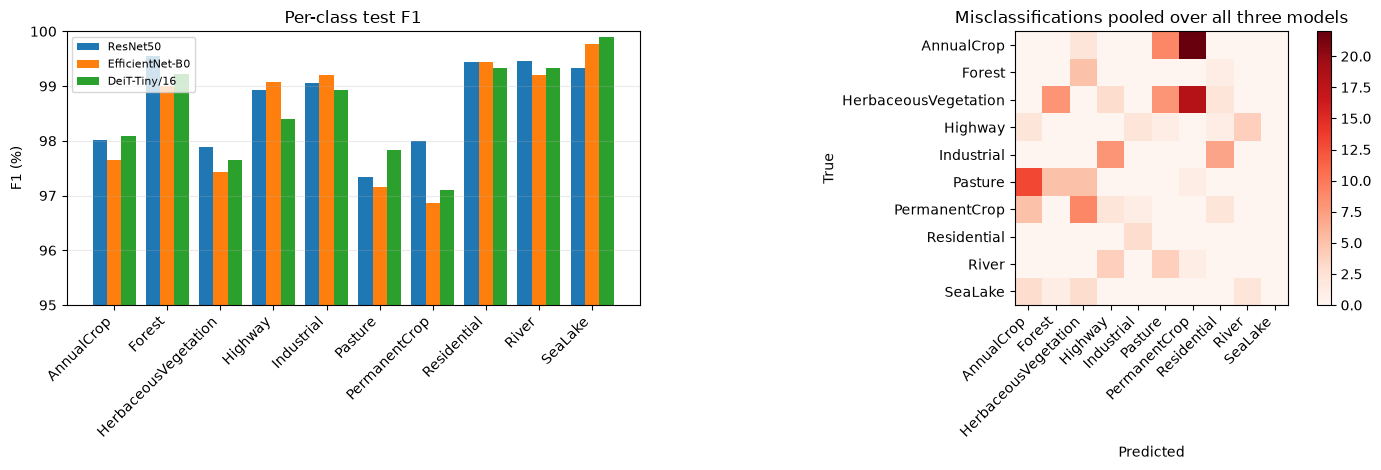

,ResNet50,EfficientNet-B0,DeiT-Tiny/16,mean
PermanentCrop,98.00,96.86,97.11,97.32
Pasture,97.33,97.15,97.84,97.44
HerbaceousVegetation,97.88,97.42,97.65,97.65
AnnualCrop,98.01,97.65,98.09,97.92
Highway,98.94,99.07,98.40,98.80
Industrial,99.06,99.20,98.93,99.06
Forest,99.56,99.01,99.22,99.26
River,99.47,99.20,99.33,99.33
Residential,99.45,99.45,99.34,99.41
SeaLake,99.33,99.78,99.89,99.66


,class pair,errors (3 models pooled)
0,HerbaceousVegetation <-> PermanentCrop,27
1,AnnualCrop <-> PermanentCrop,27
2,AnnualCrop <-> Pasture,22
3,HerbaceousVegetation <-> Pasture,13
4,Forest <-> HerbaceousVegetation,13
5,Industrial <-> Residential,10


The 4 agricultural classes account for 92 of 167 pooled errors (55.1%), from 6 of the 45 possible class pairs.


In [ ]:
# 10.2 Where do the errors actually live? Per-class F1 and pooled confusions.
per_class_f1 = pd.DataFrame(
    {name: np.asarray(m["f1_per_class"]) * 100 for name, _, _, m in MODEL_RESULTS},
    index=CLASS_NAMES,
)
per_class_f1["mean"] = per_class_f1.mean(axis=1)
per_class_f1 = per_class_f1.sort_values("mean").round(2)

pooled_errors = sum(np.asarray(m["confusion_matrix"], dtype=float) for _, _, _, m in MODEL_RESULTS)
np.fill_diagonal(pooled_errors, 0)

figure, axes = plt.subplots(1, 2, figsize=(14, 4.8))
positions = np.arange(10)
for offset, (name, _, _, metrics) in zip([-0.27, 0.0, 0.27], MODEL_RESULTS):
    axes[0].bar(positions + offset, np.asarray(metrics["f1_per_class"]) * 100, width=0.27, label=name)
axes[0].set_xticks(positions, CLASS_NAMES, rotation=45, ha="right")
axes[0].set(title="Per-class test F1", ylabel="F1 (%)", ylim=(95, 100))
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.25, axis="y")

image = axes[1].imshow(pooled_errors, cmap="Reds")
axes[1].set_xticks(positions, CLASS_NAMES, rotation=45, ha="right")
axes[1].set_yticks(positions, CLASS_NAMES)
axes[1].set(title="Misclassifications pooled over all three models",
            xlabel="Predicted", ylabel="True")
figure.colorbar(image, ax=axes[1], fraction=0.046)
figure.tight_layout()
plt.show()

symmetric_pairs = sorted(
    ((pooled_errors[i, j] + pooled_errors[j, i], CLASS_NAMES[i], CLASS_NAMES[j])
     for i in range(10) for j in range(i + 1, 10)),
    reverse=True,
)
worst_pairs = pd.DataFrame(
    [{"class pair": f"{a} <-> {b}", "errors (3 models pooled)": int(count)}
     for count, a, b in symmetric_pairs[:6]]
)

AGRICULTURAL = {"AnnualCrop", "HerbaceousVegetation", "Pasture", "PermanentCrop"}
agricultural_errors = sum(
    count for count, a, b in symmetric_pairs if a in AGRICULTURAL and b in AGRICULTURAL
)

display(per_class_f1)
display(worst_pairs)
print(f"The 4 agricultural classes account for "
      f"{agricultural_errors:.0f} of {pooled_errors.sum():.0f} pooled errors "
      f"({agricultural_errors / pooled_errors.sum() * 100:.1f}%), "
      f"from 6 of the 45 possible class pairs.")

## 11. Comparison with published results

The published EuroSAT benchmark provides an external reference for our results.

**Protocol difference.** Helber et al. use an 80/20 train/test split with no
validation set (21,600 training images). We use a stratified 70/15/15 split (18,900 training
images) so that checkpoint selection never touches test data. Our training split contains
2,700 fewer images and our test set is smaller, so the comparison is indicative rather than
exact.

In [ ]:
# 11.1 Our results against the published EuroSAT benchmark (RGB).
published_results = pd.DataFrame([
    {"source": "Helber et al. 2019", "model": "ResNet-50 (fine-tuned)",
     "split": "80/20", "train images": 21_600, "accuracy %": 98.57},
    {"source": "Helber et al. 2019", "model": "GoogLeNet (fine-tuned)",
     "split": "80/20", "train images": 21_600, "accuracy %": 98.18},
    {"source": "Helber et al. 2019", "model": "ResNet-50 (from scratch)",
     "split": "80/20", "train images": 21_600, "accuracy %": 96.43},
    {"source": "Helber et al. 2019", "model": "GoogLeNet (from scratch)",
     "split": "80/20", "train images": 21_600, "accuracy %": 96.02},
    {"source": "Helber et al. 2019", "model": "Shallow CNN (2 layers)",
     "split": "80/20", "train images": 21_600, "accuracy %": 87.96},
    {"source": "Helber et al. 2019", "model": "BoVW + SVM (SIFT, k=500)",
     "split": "80/20", "train images": 21_600, "accuracy %": 70.05},
])
our_results = pd.DataFrame([
    {"source": "This project", "model": name, "split": "70/15/15", "train images": 18_900,
     "accuracy %": round(metrics["accuracy"] * 100, 2)}
    for name, _, _, metrics in MODEL_RESULTS
])

benchmark_table = pd.concat([published_results, our_results], ignore_index=True)
benchmark_table = benchmark_table.sort_values("accuracy %", ascending=False, ignore_index=True)
display(benchmark_table)

published_best = 98.57
our_best_name = comparison["test accuracy %"].idxmax()
our_best = comparison["test accuracy %"].max()
print(f"Best published fine-tuned result : {published_best:.2f}% (ResNet-50, 21,600 train images)")
print(f"Our best                         : {our_best:.2f}% ({our_best_name}, 18,900 train images)")
print(f"Difference                       : {our_best - published_best:+.2f} pp "
      f"using {21_600 - 18_900:,} fewer training images")
print(f"Pretrained vs from-scratch gap reported by Helber et al.: "
      f"{98.57 - 96.43:+.2f} pp")

,source,model,split,train images,accuracy %
0,This project,ResNet50,70/15/15,18900,98.74
1,This project,DeiT-Tiny/16,70/15/15,18900,98.62
2,Helber et al. 2019,ResNet-50 (fine-tuned),80/20,21600,98.57
3,This project,EfficientNet-B0,70/15/15,18900,98.52
4,Helber et al. 2019,GoogLeNet (fine-tuned),80/20,21600,98.18
5,Helber et al. 2019,ResNet-50 (from scratch),80/20,21600,96.43
6,Helber et al. 2019,GoogLeNet (from scratch),80/20,21600,96.02
7,Helber et al. 2019,Shallow CNN (2 layers),80/20,21600,87.96
8,Helber et al. 2019,"BoVW + SVM (SIFT, k=500)",80/20,21600,70.05


Best published fine-tuned result : 98.57% (ResNet-50, 21,600 train images)
Our best                         : 98.74% (ResNet50, 18,900 train images)
Difference                       : +0.17 pp using 2,700 fewer training images
Pretrained vs from-scratch gap reported by Helber et al.: +2.14 pp


## 12. Sample efficiency and seed variance

We repeat each model across four training-set sizes and three seeds to measure sample efficiency
and run-to-run variation.

Every (model, training-set fraction, seed) combination below follows the protocol in Section
6.1. Only the training subset and seed change. Training
subsets are stratified (class-proportional) subsamples; validation and test sets are always
the full, untouched splits, so every point is evaluated on identical data. Each run selects its
checkpoint using validation macro-F1 and evaluates the test set once; test results do not affect
training or selection.

| Axis | Values |
|---|---|
| Training fraction | 10% (1,890), 25% (4,727), 50% (9,450), 100% (18,900 images) |
| Model | ResNet50, EfficientNet-B0, DeiT-Tiny/16 |
| Seed | 1, 2, 3 |

Helber et al. report training-set-size curves only for randomly initialised
networks (their Table II); their fine-tuned results appear at a single 80/20 point (Table III).
They do not report sample-efficiency curves for pretrained models on EuroSAT. The three
full-data seeds also provide error bars for the single-seed comparison in Section 10.

Each completed run appends one row to
`outputs/sample_efficiency/results.csv`; completed combinations are skipped on re-execution.
A complete file loads in seconds. Deleting it reruns all 36 combinations (~3 GPU-hours).

In [ ]:
# 12.1 Sweep implementation. Reuses the Section 6 harness (run_epoch) and the
# Section 7-9 model factories; only the training subset and seed vary.
from torch.utils.data import DataLoader, Subset

SWEEP_DIR = PROJECT_ROOT / "outputs" / "sample_efficiency"
SWEEP_DIR.mkdir(parents=True, exist_ok=True)
SWEEP_CSV = SWEEP_DIR / "results.csv"

SWEEP_FRACTIONS = (0.10, 0.25, 0.50, 1.00)
SWEEP_SEEDS = (1, 2, 3)
SWEEP_MODELS = {
    "resnet50": ("ResNet50", create_resnet50),
    "efficientnet_b0": ("EfficientNet-B0", create_efficientnet_b0),
    "deit_tiny": ("DeiT-Tiny/16", create_deit_tiny),
}


def stratified_subset_indices(dataset, fraction, seed):
    """Class-proportional subsample of the training split, reproducible from `seed`."""
    if fraction >= 1.0:
        return list(range(len(dataset)))
    class_ids = dataset.samples["class_id"].to_numpy()
    generator = np.random.default_rng(seed)
    selected = []
    for class_id in np.unique(class_ids):
        pool = np.flatnonzero(class_ids == class_id)
        keep = max(1, int(round(len(pool) * fraction)))
        selected.extend(generator.choice(pool, size=keep, replace=False).tolist())
    return sorted(selected)


def sweep_train_one(model_key, fraction, seed):
    """One full training run under the Section 6.1 protocol; returns a results row."""
    _, factory = SWEEP_MODELS[model_key]
    set_seed(seed)
    model = factory(len(CLASS_NAMES)).to(device)

    indices = stratified_subset_indices(data.train_dataset, fraction, seed)
    loader_generator = torch.Generator()
    loader_generator.manual_seed(seed)
    train_loader = DataLoader(
        Subset(data.train_dataset, indices),
        batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS,
        pin_memory=device.type == "cuda", persistent_workers=NUM_WORKERS > 0,
        generator=loader_generator,
    )

    criterion = nn.CrossEntropyLoss()
    optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=LEARNING_RATE * 0.01)
    use_amp = device.type == "cuda"
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

    best_val_macro_f1, best_epoch, best_state = -1.0, 0, None
    started = time.perf_counter()
    for epoch in range(1, EPOCHS + 1):
        run_epoch(model, train_loader, criterion, device, len(CLASS_NAMES),
                  optimizer=optimizer, scaler=scaler, use_amp=use_amp)
        val_metrics = run_epoch(model, loaders["validation"], criterion, device,
                                len(CLASS_NAMES), use_amp=use_amp)
        if val_metrics["macro_f1"] > best_val_macro_f1:
            best_val_macro_f1 = val_metrics["macro_f1"]
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        scheduler.step()
    training_seconds = time.perf_counter() - started

    model.load_state_dict(best_state)
    test_metrics = run_epoch(model, loaders["test"], criterion, device,
                             len(CLASS_NAMES), use_amp=use_amp)
    del model
    if device.type == "cuda":
        torch.cuda.empty_cache()

    return {
        "model": model_key, "fraction": fraction, "seed": seed,
        "train_images": len(indices), "epochs": EPOCHS, "best_epoch": best_epoch,
        "val_macro_f1": best_val_macro_f1,
        "test_accuracy": test_metrics["accuracy"],
        "test_macro_f1": test_metrics["macro_f1"],
        "training_seconds": round(training_seconds, 1),
        "f1_per_class": json.dumps([round(v, 6) for v in test_metrics["f1_per_class"]]),
    }


completed = set()
if SWEEP_CSV.is_file():
    completed = {(row.model, round(row.fraction, 4), int(row.seed))
                 for row in pd.read_csv(SWEEP_CSV).itertuples()}

schedule = [(seed, fraction, key) for seed in SWEEP_SEEDS
            for fraction in SWEEP_FRACTIONS for key in SWEEP_MODELS]
todo = [job for job in schedule if (job[2], round(job[1], 4), job[0]) not in completed]
print(f"Sweep: {len(schedule) - len(todo)}/{len(schedule)} runs already recorded, "
      f"{len(todo)} to train now")

for seed, fraction, key in todo:
    print(f"  training {key}  fraction={fraction:.2f}  seed={seed} ...", flush=True)
    row = sweep_train_one(key, fraction, seed)
    pd.DataFrame([row]).to_csv(SWEEP_CSV, mode="a", header=not SWEEP_CSV.is_file(), index=False)
    print(f"    test_acc={row['test_accuracy']*100:.2f}%  ({row['training_seconds']:.0f}s)")

sweep_results = pd.read_csv(SWEEP_CSV).drop_duplicates(["model", "fraction", "seed"])
assert len(sweep_results) >= len(schedule), "sweep incomplete"
print(f"Loaded {len(sweep_results)} runs from {SWEEP_CSV.relative_to(PROJECT_ROOT)}")

Sweep: 36/36 runs already recorded, 0 to train now
Loaded 36 runs from outputs/sample_efficiency/results.csv


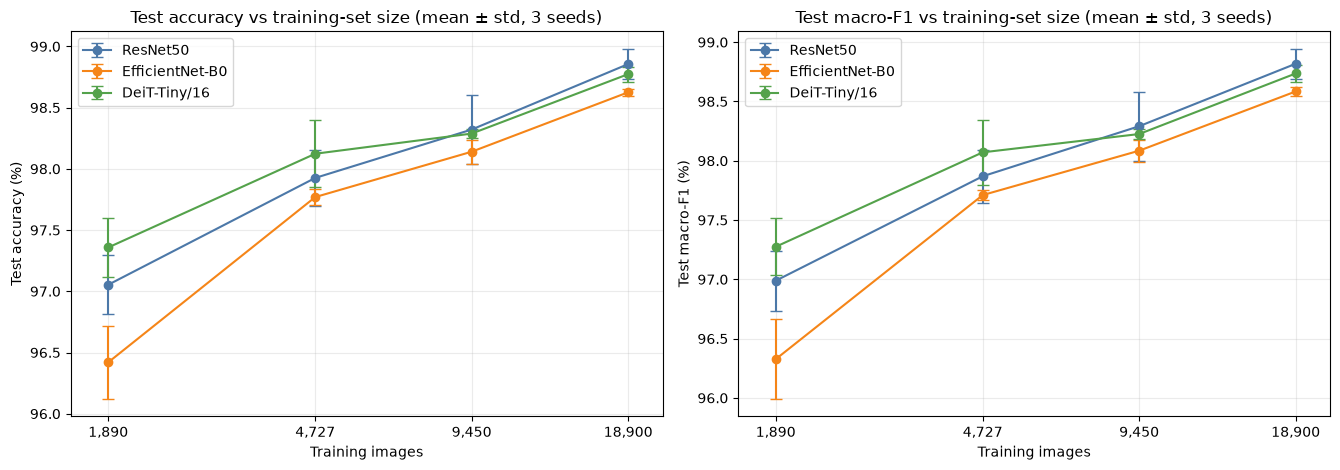

display,DeiT-Tiny/16,EfficientNet-B0,ResNet50
train_images,,,
1890,97.36 ± 0.24,96.42 ± 0.3,97.05 ± 0.24
4727,98.12 ± 0.27,97.77 ± 0.06,97.93 ± 0.23
9450,98.29 ± 0.04,98.14 ± 0.1,98.32 ± 0.28
18900,98.77 ± 0.06,98.63 ± 0.03,98.86 ± 0.12


Model spread at  1,890 images: 0.94 pp
Model spread at 18,900 images: 0.23 pp
Largest seed std at any point : 0.30 pp


In [ ]:
# 12.2 Sample-efficiency curves with seed error bars.
DISPLAY_NAMES = {key: name for key, (name, _) in SWEEP_MODELS.items()}
sweep_results = sweep_results.assign(display=sweep_results["model"].map(DISPLAY_NAMES))

aggregated = (
    sweep_results.groupby(["display", "train_images"], as_index=False)
    .agg(mean_acc=("test_accuracy", "mean"), std_acc=("test_accuracy", "std"),
         mean_f1=("test_macro_f1", "mean"), std_f1=("test_macro_f1", "std"))
)

figure, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
for name, colour in zip(["ResNet50", "EfficientNet-B0", "DeiT-Tiny/16"],
                        ["#4C78A8", "#F58518", "#54A24B"]):
    subset = aggregated[aggregated["display"] == name].sort_values("train_images")
    for axis, mean_col, std_col in [(axes[0], "mean_acc", "std_acc"),
                                    (axes[1], "mean_f1", "std_f1")]:
        axis.errorbar(subset["train_images"], subset[mean_col] * 100,
                      yerr=subset[std_col] * 100, marker="o", capsize=4,
                      label=name, color=colour)
axes[0].set(title="Test accuracy vs training-set size (mean ± std, 3 seeds)",
            xlabel="Training images", ylabel="Test accuracy (%)")
axes[1].set(title="Test macro-F1 vs training-set size (mean ± std, 3 seeds)",
            xlabel="Training images", ylabel="Test macro-F1 (%)")
for axis in axes:
    axis.set_xscale("log")
    axis.set_xticks([1890, 4727, 9450, 18900], ["1,890", "4,727", "9,450", "18,900"])
    axis.tick_params(axis="x", which="minor", bottom=False, labelbottom=False)
    axis.set_xlim(1600, 22000)
    axis.grid(alpha=0.25)
    axis.legend()
figure.tight_layout()
plt.show()

accuracy_pivot = aggregated.assign(
    formatted=(aggregated["mean_acc"] * 100).round(2).astype(str) + " ± "
              + (aggregated["std_acc"] * 100).round(2).astype(str)
).pivot(index="train_images", columns="display", values="formatted")
display(accuracy_pivot)

low_data = aggregated[aggregated["train_images"] == 1890]
full_data = aggregated[aggregated["train_images"] == 18900]
print(f"Model spread at  1,890 images: "
      f"{(low_data['mean_acc'].max() - low_data['mean_acc'].min()) * 100:.2f} pp")
print(f"Model spread at 18,900 images: "
      f"{(full_data['mean_acc'].max() - full_data['mean_acc'].min()) * 100:.2f} pp")
print(f"Largest seed std at any point : {aggregated['std_acc'].max() * 100:.2f} pp")

## 13. Discussion

### 13.1 Full-data accuracy and model size

Across three seeds, mean test accuracy is 98.86% for ResNet50, 98.77% for DeiT-Tiny and 98.63%
for EfficientNet-B0. The single seed-42 runs in Sections 7-9 range from 98.52% to 98.74%.
ResNet50 has the highest mean, with only 0.09 points separating it from DeiT-Tiny and 0.23
points from EfficientNet-B0. It also has 4-6x as many parameters and a checkpoint 4-6x larger.

The two compact models retain nearly all of ResNet50's accuracy under this protocol. Their
smaller checkpoints may matter in storage-constrained settings, although we did not measure
deployment latency or memory use.

### 13.2 Stability across the three tested seeds

We measured variation across seeds and across two implementations. At full data, ResNet50
ranges from 98.74% to 98.99% (std 0.12), DeiT-Tiny from 98.72% to 98.84% (0.06), and
EfficientNet-B0 from 98.59% to 98.64% (0.03). The largest standard deviation at any point in
the sweep is 0.30 points.

A separate script implementation gives ResNet50 98.52% at seed 42, compared with 98.74% in the
notebook. The run artefacts are stored in `outputs/local_gpu_resnet50_20260727/`. The two
implementations differ in incidental settings such as deterministic-algorithm flags and the
number of dataloader workers.

These variations are comparable to the gaps between models in a single run. The seed-42 results
also fall near the lower end of their respective seed ranges, so they do not support a stable
ranking on their own.

The 0.09-point full-data gap between ResNet50 and DeiT-Tiny lies within the observed seed
variation. Their ordering remains unresolved at n=3. EfficientNet-B0 has the lowest mean at
each training-set size and the smallest full-data standard deviation, but three seeds are not
enough for a formal significance claim. DeiT-Tiny has the highest mean in the low-data runs,
examined in Section 13.4.

### 13.3 Errors in the agricultural classes

The per-class results are similar across architectures. PermanentCrop, Pasture,
HerbaceousVegetation and AnnualCrop are the four lowest-F1 classes for every model, with scores
between 96.9% and 98.1%. Every remaining class reaches at least 98.8%. Pooled across the three
models, the four agricultural classes account for 55% of all errors. They represent only 6 of
the 45 possible class pairs.

This matches the EuroSAT authors' observation that their best classifier "sometimes confuses
the agricultural land classes". The same failure mode appears in three separately trained
architectures from convolutional and attention-based model families. The pattern is consistent
with ambiguity and limited image resolution, but it does not establish that these errors are
inherent to the dataset. Other models or training methods may still improve these classes.

Annual crops, permanent crops, pasture and herbaceous vegetation share field textures that are
distinguished mainly by crop cycle and land management. Those properties are weakly observable
in a single 640 m x 640 m RGB patch. Section 5.4 also shows that the most confused pairs are not
the closest in average colour. The useful signal is therefore spatial and textural, and some of
it falls below the 10 m ground resolution.

### 13.4 Sample efficiency

Helber et al. report training-set-size curves for randomly initialised networks, whereas their
fine-tuned models are evaluated at a single split. In our pretrained-model sweep, the
mean-to-mean spread is 0.94 points at 1,890 training images, 0.35 at 4,727, 0.18 at 9,450 and
0.23 at 18,900. The largest difference occurs at the smallest training size and the models are
much closer thereafter.

DeiT-Tiny has the highest mean at 1,890 and 4,727 images. At 1,890 images it leads
EfficientNet-B0 by 0.94 points and ResNet50 by 0.31 points; the larger margin exceeds the
observed per-point standard deviations. ResNet50 overtakes at about 9,450 images, where the gap
is already within the observed standard deviations. The pretrained transformer is not more
data-hungry within the range tested here. Its lower parameter count could reduce overfitting at
about 189 images per class, although we did not test that mechanism directly.

### 13.5 Limitations

Three seeds provide only two degrees of freedom for each standard-deviation estimate. More
runs are needed to resolve small gaps such as ResNet50 versus DeiT-Tiny at full data, with GPU
cost increasing linearly.

The random split ignores spatial autocorrelation. Section 4 rules out duplicated files across
splits, but EuroSAT patches come from a limited number of Sentinel-2 scenes. Geographically
adjacent patches can therefore appear in different partitions and share acquisition conditions
or land-management practices. This can inflate accuracy on both our split and the published
benchmark. A split by country or scene would better estimate generalisation to a new region.

We use only 3 of the 13 Sentinel-2 bands. Helber et al. report 98.57% for RGB, 98.30% for
colour-infrared and 97.05% for short-wave infrared with fine-tuned models. They attribute RGB's
advantage to ImageNet pretraining. A model designed for near-infrared and red-edge inputs may
improve discrimination between crop types.

The fixed 20-epoch budget may favour the CNNs. DeiT-Tiny selected epoch 20 as its best checkpoint
in the seed-42 run, whereas ResNet50 and EfficientNet-B0 peaked at epochs 17 and 19. Longer
training could change the comparison.

We did not run our own random-initialisation ablation. Helber et al.'s Table II provides the
reference: 96.43% from scratch and 98.57% after fine-tuning ResNet-50 on their 80/20 split.

### 13.6 Future work

1. Adapt the first convolution or patch embedding to 13 channels, then measure whether the
   additional bands improve classification of the agricultural classes.
2. Apply Grad-CAM or attention rollout to agricultural errors. This would test whether the
   models rely on field texture and help distinguish ambiguous examples from label noise.
3. Re-partition the data by country or scene to measure generalisation without cross-split
   spatial autocorrelation.
4. Add 1% and 5% training tiers to determine whether DeiT-Tiny's low-data advantage persists
   below the range tested here.

## 14. Conclusion

Across three seeds, ResNet50, EfficientNet-B0 and DeiT-Tiny/16 reach 98.63-98.86% mean test
accuracy on the fixed EuroSAT split. ResNet50 produces the best single run at 98.99%. These
results are comparable to the published 98.57% benchmark despite using 2,700 fewer training
images, and all nine full-data runs exceed the published 96.43% result from random
initialisation.

Full-data accuracy differs by only 0.23 points despite large differences in parameter count.
EfficientNet-B0 uses 4.0M parameters and trails the 23.5M-parameter ResNet50 by 0.23 points;
the 5.5M-parameter DeiT-Tiny trails by 0.09. Deployment performance was
not measured, so the smaller checkpoints should not be treated as evidence of lower latency.

All three models make most of their remaining mistakes on the agricultural classes. These
classes account for 55% of pooled errors and are difficult to separate by crop cycle in a
single 10 m-resolution RGB image. The shared pattern agrees with the original EuroSAT paper
and is consistent with ambiguity in the data, although it does not rule out improvement from
other models or training methods.

The largest differences appear at 1,890 training images, where DeiT-Tiny has the highest mean.
The gaps are smaller at the three larger training sizes. EfficientNet-B0 has the lowest mean at every tested
data size, but three seeds are insufficient for a formal significance claim or for ordering
ResNet50 and DeiT-Tiny at full data. A geographically disjoint split is also needed because the
current random split does not remove spatial autocorrelation.

## References

1. Helber, P., Bischke, B., Dengel, A., and Borth, D. (2019). *EuroSAT: A Novel Dataset and Deep Learning Benchmark for Land Use and Land Cover Classification*. IEEE JSTARS, 12(7), 2217-2226.
2. He, K., Zhang, X., Ren, S., and Sun, J. (2016). *Deep Residual Learning for Image Recognition*. CVPR.
3. Tan, M., and Le, Q. V. (2019). *EfficientNet: Rethinking Model Scaling for Convolutional Neural Networks*. ICML.
4. Touvron, H. et al. (2021). *Training Data-Efficient Image Transformers & Distillation through Attention*. ICML.